In [1]:
#六角形ベースでABC分割をしたい(v2)ABCはそれぞれ六角形1個　mpirunできるようにする

10 10
pg= 0.5 TEE_aved= 0.0 TEE_error=0.000 TEE_vard=0.000
pg= 1.0 TEE_aved= -1.0 TEE_error=0.000 TEE_vard=0.000
Np= 2 Nd= 10 NT= 1200 time= 12


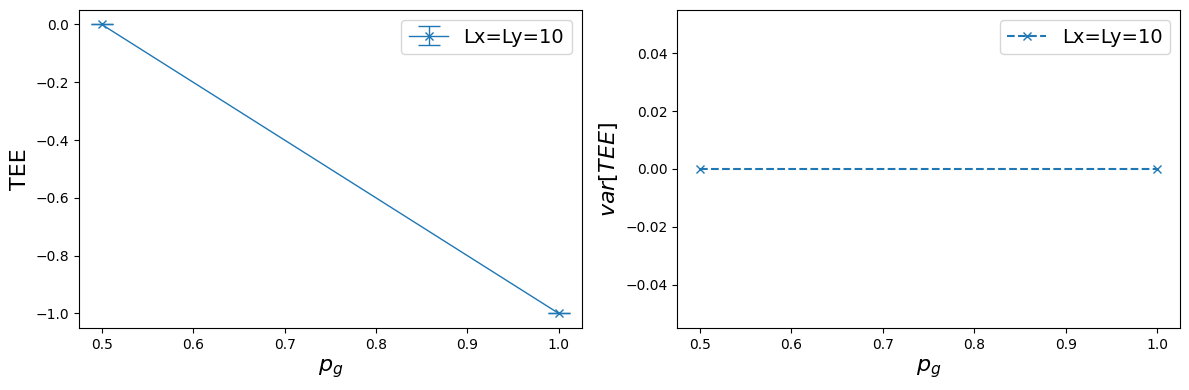

In [9]:
from __future__ import print_function, division
import sys,os
# line 4 and line 5 below are for development purposes and ca be removed
qspin_path = os.path.join(os.getcwd(),"../../")
sys.path.insert(0,qspin_path)
from quspin.operators import hamiltonian # Hamiltonians and operators
#from quspin.basis import spinless_fermion_basis_1d # Hilbert space fermion basis
from quspin.basis import spin_basis_1d # Hilbert space spin basis
import numpy as np # generic math functions
import matplotlib.pyplot as plt # plotting library
from scipy.linalg import expm, sinm, cosm
from numpy.linalg import multi_dot
from scipy.sparse import csr_matrix, csc_matrix, coo_matrix, lil_matrix
from scipy.sparse.linalg import inv, eigs
from scipy.linalg import svdvals
from scipy.stats import unitary_group
from scipy import linalg
from numpy import linalg as LA
import pylab
import time
import numba
from numba import njit,c16,i8,u2
import sys
import math

np.set_printoptions(precision=2)
np.set_printoptions(suppress=True)
np.set_printoptions(threshold=np.inf, linewidth=np.inf)

time_start = time.time()

def idx(x,y,Lx,Ly):
    return (x % Lx) + Lx * (y % Ly)
def inv_idx(i,Lx,Ly):
    return i % Lx, i // Lx


def dir_x(x,y,Lx,Lv):
    return x+Lx*y
def dir_y(x,y,Lx,Lv):
    return x+Lx*y+Lv
def dir_xy(x,y,Lx,Lv):
    return x+Lx*y+2*Lv


def create_transformation_pv_link(Lv, Lx, Ly):
    #############################################
    ############ plaquette part #################
    #############################################
    p_indd = np.zeros((2*Lx*Ly,3),dtype='uint32')
    for iy in range(Ly):
        for ix in range(Lx):
            #下三角
            ic=(ix%Lx)+Lx*(iy%Ly)
            ipx=(ix+1)%Lx
            ipy=(iy+1)%Ly
            p_indd[ic][0]=dir_x(ix,iy,Lx,Lv)
            p_indd[ic][1]=dir_y(ipx,iy,Lx,Lv)
            p_indd[ic][2]=dir_xy(ix,iy,Lx,Lv)
            #上三角
            p_indd[ic+Lx*Ly][0]=dir_xy(ix,iy,Lx,Lv)
            p_indd[ic+Lx*Ly][1]=dir_x(ix,ipy,Lx,Lv)
            p_indd[ic+Lx*Ly][2]=dir_y(ix,iy,Lx,Lv)

    ############################################
    ############ vertex part ###################
    ############################################
    v_indd = np.zeros((Lx*Ly,6),dtype='uint32')
    for iy in range(Ly):
        for ix in range(Lx):
            ic=(ix%Lx)+Lx*(iy%Ly)
            imx=(ix-1)%Lx
            imy=(iy-1)%Ly
            v_indd[ic][0]=dir_x(ix,iy,Lx,Lv)
            v_indd[ic][1]=dir_xy(ix,iy,Lx,Lv)
            v_indd[ic][2]=dir_y(ix,iy,Lx,Lv)
            v_indd[ic][3]=dir_x(imx,iy,Lx,Lv)
            v_indd[ic][4]=dir_xy(imx,imy,Lx,Lv)
            v_indd[ic][5]=dir_y(ix,imy,Lx,Lv)
    #print(v_indd)
    #print(p_indd)
    return p_indd, v_indd


####################################################
def initial_stabilizer_state(case,Ld,Lxd,Lyd,v_ind,p_ind):
    # Ld: total # of qubits
    MRi=np.zeros((Ld,2*Ld),dtype='uint32')
    if case == 1:
        #Case I: X product state
        for ii in range(Ld):
            MRi[ii][ii]=1 # X
    if case == 2:
        #Case I: Z product state
        for ii in range(Ld):
            MRi[ii][Ld+ii]=1 # Z
    if case ==3:
        ##Case III: unique g.s. of TC 
        ### plaquette stabilizers ZZZ ###
        for ip in range(2*Lxd*Lyd-1):
            MRi[ip][Ld+p_ind[ip][0]]=1 # Z0
            MRi[ip][Ld+p_ind[ip][1]]=1 # Z1
            MRi[ip][Ld+p_ind[ip][2]]=1 # Z2
            #独立ではない最後のBpだけ取らない
        ### vertex stabilizers  XXXXXX ###
        for iv in range((Lxd)*(Lyd)-1):
            ivs=iv+2*Lxd*Lyd-1  # note that iv and ivs are different.
            MRi[ivs][v_ind[iv][0]]=1 # X0
            MRi[ivs][v_ind[iv][1]]=1 # X1
            MRi[ivs][v_ind[iv][2]]=1 # X2
            MRi[ivs][v_ind[iv][3]]=1 # X3
            MRi[ivs][v_ind[iv][4]]=1 # X4
            MRi[ivs][v_ind[iv][5]]=1 # X5
            #独立ではない最後のAvだけ取らない
        ### Add logical operators###
            # x-direction loop logical Z
            for kk in range(Lx):
                iv=(kk%Lx)+Lx*(0%Ly)
                MRi[Ld-2][Ld+v_ind[iv][0]]=0 #Z
            # x-direction loop logical Z
            for kk in range(Ly):
                iv=(0%Lx)+Lx*(kk%Ly)
                MRi[Ld-1][Ld+v_ind[iv][1]]=0 #Z
    #print(MRi)
    return MRi

####################################################
def measurement_op(dMR,Ld,Lxd,Lyd,v_ind,p_ind,Gcd,mtyped):
    Meo=np.zeros(2*Ld,dtype='uint32')
    #
    if mtyped==1: #plaquette or star operator
        todo=[0,1]
        prob_list = [0.5,0.5]
        vorp = np.random.choice(todo,size=None,replace=True, p=prob_list)
        if vorp==0:
            todo=np.arange(Lxd*Lyd)
            vp=np.random.choice(todo,size=None,replace=True,p=None)
            #please check
            Meo[v_ind[vp][0]]=1 #X0
            Meo[v_ind[vp][1]]=1 #X1
            Meo[v_ind[vp][2]]=1 #X2
            Meo[v_ind[vp][3]]=1 #X3
            Meo[v_ind[vp][4]]=1 #X4
            Meo[v_ind[vp][5]]=1 #X5
        else:
            todo=np.arange(2*Lxd*Lyd)
            pp=np.random.choice(todo,size=None,replace=True,p=None)
            #please check
            Meo[Ld+p_ind[pp][0]]=1 #Z0
            Meo[Ld+p_ind[pp][1]]=1 #Z1
            Meo[Ld+p_ind[pp][2]]=1 #Z2
            
    if mtyped==2: #local X
        todo=np.arange(Ld)
        mp=np.random.choice(todo,size=None,replace=True,p=None)
        #please check
        Meo[mp]=1 #X0
        
    if mtyped==3: #local Z
        todo=np.arange(Ld)
        mp=np.random.choice(todo,size=None,replace=True,p=None)
        #please check
        Meo[Ld+mp]=1 #X0
    
    # Meo without outcome sign
    MeoF=np.zeros(2*Ld,dtype='uint32')
    MeoF=Meo
    
    # dMR without foctor
    dMRF=np.zeros((Ld,2*Ld),dtype='uint32')
    dMRF=dMR
    #check anti commtation
    Mgs=np.dot(dMRF,np.dot(Gcd,MeoF.T))
    Mgs=Mgs%2  ## check: reduce Z2 value 
    
    antic_index_list=[]
    aid=np.where(Mgs[:]!=0)
    antic_index_list=aid[0]
    #######
    lenMe=len(antic_index_list)
    if lenMe !=0:
        kc=antic_index_list[0]
        dMR_prev=dMR[kc].copy()
        #replace stabilizer for kc
        dMR[kc]=Meo
        update_list=np.delete(antic_index_list,0)
        dMR[update_list,:]=np.mod(dMR[update_list,:]+dMR_prev,2)
    return dMR

def subset2(Ld,Ax,Ay,Lx,Ly,p_indd):
    i = idx(Ax,Ay,Lx,Ly)
    Asub_set = set()
    for j in range(3):
        Asub_set.add(p_indd[i][j]) #三角形
        Asub_set.add(p_indd[i + Lx*Ly][j]) #逆三角形
        print(p_indd[i][j])
        print(p_indd[i + Lx*Ly][j])
    return Asub_set

def subset6(Ld,Ax,Ay,Lx,Ly,p_indd):
    Asub_set = set()
    Amx=(Ax - 1) % Lx
    Amy=(Ay - 1) % Ly
    i0 = idx(Ax,Ay,Lx,Ly)
    i1 = idx(Amx,Amy,Lx,Ly)
    i2 = idx(Amx,Ay,Lx,Ly)
    i3 = idx(Ax,Amy,Lx,Ly)
    for j in range(3):
        Asub_set.add(p_indd[i0][j])
        Asub_set.add(p_indd[i0 + Lx*Ly][j])
        Asub_set.add(p_indd[i1][j])
        Asub_set.add(p_indd[i1 + Lx*Ly][j])
        Asub_set.add(p_indd[i2][j])
        Asub_set.add(p_indd[i3+Lx*Ly][j])
    return Asub_set

# https://arxiv.org/abs/2204.08489
def EE_cal(MRd,Asub_set,Ld):
    # partition #
    #LA=Ld//2
    Asub=list(Asub_set)
    LA=len(Asub)
    MRdA=np.zeros((Ld,2*(len(Asub))),dtype='uint32')
    #print("new",Asub)
    for k2 in range(len(Asub)):
        MRdA[:,k2]=MRd[:,Asub[k2]].copy()
        MRdA[:,(LA)+k2]=MRd[:,(Ld)+Asub[k2]].copy()
    #print(MRdA.shape)
    #print(MRdA)
    rankA=rank_mod2_v3(MRdA)
    #print(rankA)
    EEd=rankA-(LA)
    return EEd

#############################
def rank_mod2_v3(MRdd):
    # MRdA construct
    i = 0
    Ic = MRdd.shape[0]
    Jc = MRdd.shape[1]
    for j in range(Jc):
        check_ind=np.where(MRdd[i:,j]==1)
        if len(check_ind[0]) !=0:
            if len(check_ind[0]) >1:
                elim_ind=np.delete(check_ind,0)
                MRdd[elim_ind+i,:]=np.mod(MRdd[elim_ind+i,:]+MRdd[check_ind[0][0]+i,:],2)
            MRdd[i,:],MRdd[check_ind[0][0]+i,:] = MRdd[check_ind[0][0]+i,:],MRdd[i,:].copy()
            i=i+1
    return i
############################



Np=2
Nd = 10 #800 sample number

#case1= X,case2= Z, case3= ground state of TC
case=1


fig, ax = plt.subplots(1,2,figsize=(12,4))

data_set = {}
L_list=[10]
for tmp_i in range(1):

    Lx=L_list[tmp_i]
    Ly=L_list[tmp_i]

    print(Lx,Ly)
    Lv=Lx*Ly # total # of vertex
    L=3*Lv # total # of link qubits
    Lp=2*Lv  # total # of plaquette
    NT=4*L #*L #4*L total time step
    
    p_indd, v_indd=create_transformation_pv_link(Lv, Lx, Ly)

    p_list=[]
    TEE_ave=[]
    TEE_error=[]
    TEE_var=[]
    for ip in range(0,Np,1):

        #for ip in range(len(p_list)):
        px=0.0
        pg=0.5*(1-px)*ip/(Np-1)+0.5
        pz=1-px-pg
        p_list=np.append(p_list,pg)
        # stabilizer matrix
        MR=np.zeros((L,2*L),dtype='uint32') # L * 2L matrix
        # sample set of physical quantity
        MR0=initial_stabilizer_state(case,L,Lx,Ly,v_indd,p_indd)

        ### check matrix ###
        Gc=np.zeros((2*L,2*L),dtype='uint32') # 2L * 2L matrix
        for k in range(L):
            Gc[k][L+k]=1
            Gc[L+k][k]=1  
        Gc_csr=csr_matrix(Gc)
        
        TEE_list=[]
        for ids in range(Nd):
            MR=MR0
            #measurement dynamics

            prob_list=[pg,px,pz]
            todo=[1,2,3]
            for it in range(NT):
                mtype= np.random.choice(todo,size=None,replace=True,p=prob_list)
                MR=measurement_op(MR,L,Lx,Ly,v_indd,p_indd,Gc,mtype)
                if it==NT-1:
                    Ax,Ay=Lx//2,Ly//2
                    Bx,By=Ax-2,Ay-1
                    Cx,Cy=Ax-1,Ay-2     

                    A = subset6(L,Ax,Ay,Lx,Ly,p_indd)
                    B = subset6(L,Bx,By,Lx,Ly,p_indd) - A
                    C = subset6(L,Cx,Cy,Lx,Ly,p_indd) - A -B
                    AB= A|B
                    BC= B|C
                    CA= C|A
                    ABC=AB|C
                    
                    SA=EE_cal(MR,A,L)
                    SB=EE_cal(MR,B,L)
                    SC=EE_cal(MR,C,L)
                    SAB=EE_cal(MR,AB,L)
                    SBC=EE_cal(MR,BC,L)
                    SCA=EE_cal(MR,CA,L)
                    SABC=EE_cal(MR,ABC,L)

                    TEE=SA+SB+SC-SAB-SBC-SCA+SABC
                    TEE_list=np.append(TEE_list,TEE)
                if len(TEE_list) > 0:
                    TEE_aved = np.mean(TEE_list)
                    TEE_vard = np.var(TEE_list)
                    TEE_errord = np.std(TEE_list, ddof=1) / np.sqrt(len(TEE_list))
                else:
                    TEE_aved = np.nan
                    TEE_vard = np.nan
                    TEE_errord = np.nan
        key1="Lx="+"{:}".format(Lx)+"_Ly="+"{:}".format(Ly)+"_p="+"{:.2f}".format(pg)
        data_set[key1+"TEE"] =TEE_list
        TEE_ave=np.append(TEE_ave,TEE_aved)
        TEE_error=np.append(TEE_error,TEE_errord)
        TEE_var=np.append(TEE_var,TEE_vard)

        
        #print("SA=",SA,"SB=",SB,"SC=",SC,"SAB=",SAB,"SBC=",SBC,"SCA=",SCA,"SABC=",SABC)
        print("pg=",pg,"TEE_aved=",TEE_aved,"TEE_error="+"{:.3f}".format(TEE_errord),"TEE_vard="+"{:.3f}".format(TEE_vard))

        #with open("Lx="+str(Lx)+"_Ly="+str(Ly)+"_L="+str(L)+"_T="+str(NT)+".lst", 'a') as f:
        #    f.writelines(str(pg)+'\t'+str(TEE_aved)+'\t'+str(TEE_errord)+'\t'+str(TEE_vard)+"\n")
    time_end = time.time()
    print("Np=",Np,"Nd=",Nd,"NT=",NT,"time=",int(time_end-time_start))

    ax[0].set_xlabel(r'$p_g$',fontsize=16)  # x軸ラベル
    ax[0].set_ylabel(r'TEE',fontsize=16)  # y軸ラベル
    ax[0].errorbar(p_list,TEE_ave,yerr=TEE_error, marker='x', capthick=1, capsize=8, lw=1,label='Lx=Ly='+"{:}".format(Lx))
    ax[0].legend(loc=0,fontsize=14)    # 凡例
    ax[1].set_xlabel(r'$p_g$',fontsize=16)  # x軸ラベル
    ax[1].set_ylabel(r'$var[TEE]$',fontsize=16)  # y軸ラベル
    ax[1].plot(p_list,TEE_var,'x',linestyle='dashed',label='Lx=Ly='+"{:}".format(Lx))
    ax[1].legend(loc=0,fontsize=14)    # 凡例
    np.savez_compressed("Lx="+"{:}".format(Lx)+".npz", **data_set)
fig.tight_layout()  # レイアウトの設定
plt.show()







In [35]:
import numpy as np

data = np.load("Lx=18.npz")
print(data.files)  # 保存されているキーの一覧を表示
data.close()

['Lx=18_Ly=18_p=0.50TEE', 'Lx=18_Ly=18_p=0.55TEE', 'Lx=18_Ly=18_p=0.60TEE', 'Lx=18_Ly=18_p=0.65TEE', 'Lx=18_Ly=18_p=0.70TEE', 'Lx=18_Ly=18_p=0.75TEE', 'Lx=18_Ly=18_p=0.80TEE', 'Lx=18_Ly=18_p=0.85TEE', 'Lx=18_Ly=18_p=0.90TEE', 'Lx=18_Ly=18_p=0.95TEE', 'Lx=18_Ly=18_p=1.00TEE']


In [37]:
import numpy as np

data = np.load("Lx=12.npz")
print(data['Lx=12_Ly=12_p=0.80TEE'])
data.close()

[0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
